In [439]:
import rasterio
import numpy as np
import matplotlib.pyplot as plt
from rasterio.windows import Window
import rasterio.mask
from tqdm import tqdm

from collections import defaultdict
from shapely.geometry import Point, Polygon
from shapely.geometry import mapping, shape

from skimage.feature import canny
from scipy import ndimage as ndi
from skimage.segmentation import expand_labels
from skimage.color import rgb2gray
from skimage import data
from skimage.filters import threshold_multiotsu, threshold_mean, rank, threshold_otsu
from skimage.morphology import remove_small_objects
from skimage import exposure
import skimage

import geopandas as gps
import cv2
import fiona
from shapely.geometry import box, shape

In [440]:
training_base_dir = '../../training'
training_area_fn = 'trainingArea_test.shp'
raw_image_base_dir = '../../rawImage'
raw_image_file_type = 'tif'
raw_image_prefix = 'raw'

outDir = '../../training/trainingPolygon_raw'
outFilenamePrefix = 'siteRGIr'


# # Check if the training areas and the training polygons have the same crs
# if meta['crs'].to_epsg() != trainingArea.crs.to_epsg():
#     print('Training area CRS does not match raster CRS')
#     targetCRS = meta['crs'] #Areas are less in number so conversion should be faster
#     trainingArea = trainingArea.to_crs(targetCRS)

In [441]:
import os
import rasterio
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
import scipy.ndimage as ndi
import time
from random import random

from skimage import measure
from skimage.segmentation import watershed
from skimage.feature import peak_local_max

def plotImage(image, cmap='cividis'):
    if cmap == 'random':
        colors = [(0,0,0)] + [(random(),random(),random()) for i in range(255)] #[(1,1,1)] for white background
        cmap = matplotlib.colors.LinearSegmentedColormap.from_list('new_map', colors, N=256)
    plt.subplots(figsize=(10,5))
    plt.imshow(image, cmap=cmap)
    plt.colorbar()
    plt.tight_layout()
    plt.show()

def fillHoles(image, max_hole_size=100, connectivity=4):
    '''
    image: raster mask
    pixel_threshold: The maximum area, in pixels, of a contiguous hole that will be filled. Default to be 100 pixels
    connectivity: 2-D pixel connectivity (4-connectivity or 8-connectivity)
    '''
    con=1 if connectivity==4 else 2 if connectivity==8 else print('Connectivity needs to be 4 or 8!')
    return remove_small_holes(image, max_hole_size+1, connectivity=con).astype(int)

def crownSeparationAndRelabeling(image, connectivity=8, winsize=8, separate=False):
    '''
    image: raster mask
    connectivity: 2-D pixel connectivity (4-connectivity or 8-connectivity)
    winsize: window size for local maximum filter. Depends on the smallest object that you want to keep in the image
    separate: If True, a one-pixel wide line separates the regions obtained by the watershed algorithm. The line has the label 0. 
    '''
    st = time.time()
    
    # 1. Distance Transformation
    # Calculate euclidean distance of every pixel from the crown edge 
    distTransform = ndi.distance_transform_edt(image)
#     print('calculated distance. Took', time.time()-st, 'seconds to complete the task')
    
    # 2. Locate Instance Center (i.e. Tree crown center with the highest euclidean distance from the crown edge)
    # Slide a maximum filter across the distance transform image
    ws = round(winsize)
    coords = peak_local_max(distTransform, footprint=np.ones((ws, ws)), labels=image)
    mask = np.zeros(distTransform.shape, dtype=bool)
    mask[tuple(coords.T)] = True
    if connectivity==4:
        markers, num_markers = ndi.label(mask)
    elif connectivity==8:
        markers, num_markers = ndi.label(mask, structure=np.ones((3,3)))
#     print('Located maxima. Took', time.time()-st, 'seconds to complete the task')

    # 3. Marker-controlled Watershed Segmentation
    # https://scikit-image.org/docs/stable/auto_examples/segmentation/plot_watershed.html
    relabel = watershed(-distTransform, markers=markers, mask=image, connectivity=1, watershed_line=separate)
    
#     print(f'Relabelling completed! Took', time.time()-st, 'seconds to complete the task')
    
    return relabel, markers, num_markers

def area_ecc_filter(image, area_bounds, ecc_bounds):
    """
    Filters objects in an image based on their areas.
    
    Parameters
    ----------
    image : 2d-array, int
        Labeled segmentation mask to be filtered. 
    area_bounds : tuple of ints
        Range of areas in which acceptable objects exist. This should be 
        provided in units of square pixels.
    ecc_bounds : tuple of floats 
        Range of eccentricities in which acceptable objects exist. This should be 
        provided on the range of 0 to 1.0.
        
    Returns
    -------
    im_relab : 2d-array, int
        The relabeled, filtered image.
    """
    
    # Extract the region props of the objects. 
    props = skimage.measure.regionprops(image)
    
    # Extract the areas and labels.
    areas = np.array([prop.area for prop in props])
    eccs = np.array([prop.eccentricity for prop in props])
    labels = np.array([prop.label for prop in props])

    # Make an empty image to add the approved cells.
    im_approved = np.zeros_like(image)
    
    # Threshold the objects based on area and eccentricity
    for i, _ in enumerate(areas):
        if areas[i] > area_bounds[0] and areas[i] < area_bounds[1]\
            and eccs[i] > ecc_bounds[0] and eccs[i] < ecc_bounds[1]:
                im_approved += image==labels[i]
   
    # Relabel the image.
#     print(np.sum(im_approved))
    im_filt = skimage.measure.label(im_approved > 0)

    return im_filt

In [442]:
def processImageAndWriteMask(cir, im, im_meta, im_transform, wp, method=None, dtype='uint8', ws=5, gamma=3, min_size=4, contrast_stretch=False, relabel=False, write=False):
    im[im==0] = np.median(im)
    im_ori = im
    if contrast_stretch:
        # Preprocess image with contrast stretch
        v_min, v_max = np.percentile(im, (90, 98))
        im = exposure.rescale_intensity(im, in_range=(v_min, v_max))
    im = exposure.adjust_gamma(im, gamma)
    
    # Applying Otsu threshold
    if method=='local':
        radius = 11
        footprint = disk(radius)
        local_otsu = rank.otsu(im_ori, footprint)
        print(local_otsu)
        mask = im>=local_otsu
    elif method=='percentile':
        threshold = np.percentile(im.ravel(), 98)
        print(threshold)
        mask = im>= threshold
    elif method=='edge':
        edges = canny(im, sigma=0.5)
        mask = ndi.binary_fill_holes(edges)
    else:
        thresholds = threshold_multiotsu(im, classes=3)
        mask = im >= thresholds[-1]
    
    
    # Relabel mask by separating touching crowns
    filled = fillHoles(mask, max_hole_size=100, connectivity=8) 
#     filled = expand_labels(filled, distance=1)
    
    if relabel:
        smallestCrownDiameterToBeSeparated = 3 # in m
        spatialRes = 0.6 # in m
        ws = smallestCrownDiameterToBeSeparated/spatialRes
        relabel, center, num_crown = crownSeparationAndRelabeling(filled, connectivity=8, winsize=ws, separate=True)
    else:
        relabel = skimage.measure.label(filled)
    # Create final mask by removing small objects
    mask_f = remove_small_objects(relabel, min_size=min_size, connectivity=1)
    mask_f[mask_f>=1] = 1
    
    # Write raster file
    im_meta.update({"driver": "GTiff",
                 "dtype": dtype,
                 "count": 1,
                 "height": im.shape[0],
                 "width": im.shape[1],
                 "transform": im_transform})
    fig, ax = plt.subplots(nrows=1, ncols=4, figsize=(7,7))
    ax[0].imshow(cir)
    ax[0].set_title('Colored IR')
    ax[1].imshow(im_ori)
    ax[1].set_title('Original')
    ax[2].imshow(im, cmap='magma')
    ax[2].set_title('Enhanced')
    ax[3].imshow(mask_f, vmin=0, vmax=1, cmap='gray')
    ax[3].set_title('Mask')
    [axi.set_axis_off() for axi in ax.ravel()]
    plt.tight_layout()
    plt.show()
#     print(im_meta)
    if write:
        with rasterio.open(wp, "w", nbits=1, **im_meta) as dst:
            dst.write(mask_f.astype(dtype), 1)

In [443]:
# Read the raw input images
def readInputImages(imageBaseDir, rawImageFileType, rawImagePrefix):
    """
    Reads all images with prefix ndvi_image_prefix and image_file_type datatype in the image_base_dir directory.
    """     
    
    rawImageFn = []
    for root, dirs, files in os.walk(imageBaseDir):
        for file in files:
            if file.endswith(rawImageFileType) and file.startswith(rawImagePrefix):
                 rawImageFn.append(os.path.join(root, file))
    inputImages = list(zip(rawImageFn))
    return inputImages

inputImages = readInputImages(raw_image_base_dir, raw_image_file_type, raw_image_prefix)
print(f'Found a total of {len(inputImages)} pair of raw image(s) to process!')

Found a total of 42 pair of raw image(s) to process!


Found number of training areas: 38


  0%|                                | 0/42 [00:00<?, ?it/s]

../../rawImage/raw_m_3507511_sw_18_060_20200516.tif



100%|██████████████████████| 38/38 [00:00<00:00, 811.27it/s]


../../rawImage/raw_m_3507518_se_18_060_20200516.tif



100%|█████████████████████| 38/38 [00:00<00:00, 1048.31it/s]


../../rawImage/raw_m_3507509_ne_18_060_20200516.tif



  0%|                                | 0/38 [00:00<?, ?it/s]

255.0


/Users/apm5rt/opt/anaconda3/envs/deep/lib/python3.7/site-packages/ipykernel_launcher.py:31: RuntimeWarning: invalid value encountered in true_divide


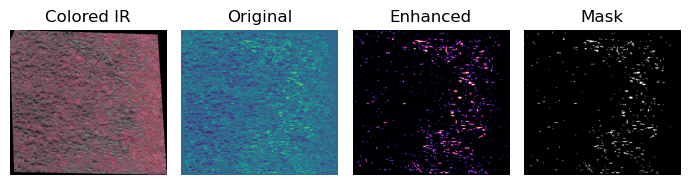


 16%|███▊                    | 6/38 [00:00<00:00, 43.68it/s]

255.0


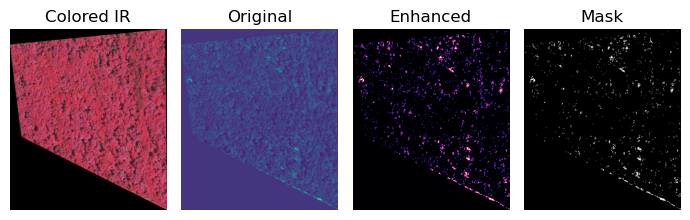


 29%|██████▋                | 11/38 [00:00<00:00, 33.63it/s]

255.0


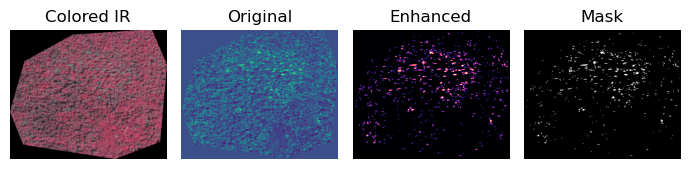


 55%|████████████▋          | 21/38 [00:00<00:00, 48.83it/s]

255.0


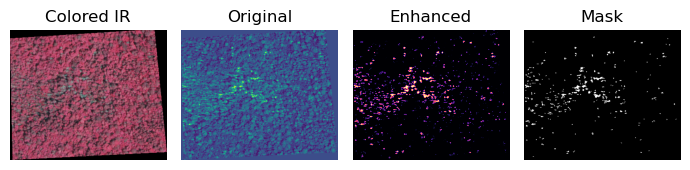


  7%|█▋                      | 3/42 [00:00<00:09,  4.11it/s]

../../rawImage/raw_m_3507518_sw_18_060_20201018.tif



100%|█████████████████████| 38/38 [00:00<00:00, 1036.86it/s]


../../rawImage/raw_m_3507608_se_18_060_20200516.tif



100%|█████████████████████| 38/38 [00:00<00:00, 1054.74it/s]


../../rawImage/raw_m_3507509_nw_18_060_20200516.tif



  0%|                                | 0/38 [00:00<?, ?it/s]

255.0


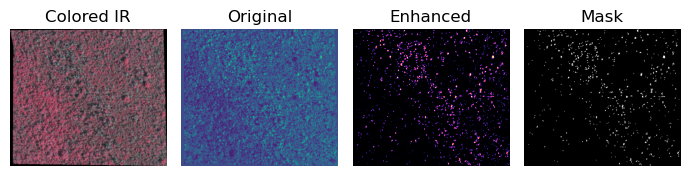


 47%|██████████▍           | 18/38 [00:00<00:00, 122.88it/s]

255.0


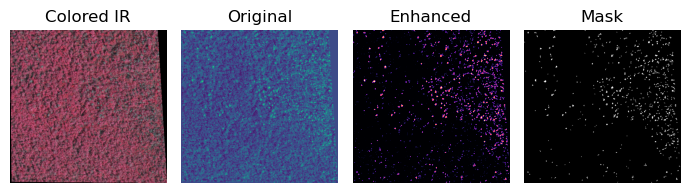


 14%|███▍                    | 6/42 [00:01<00:06,  5.66it/s]

../../rawImage/raw_m_3507502_nw_18_060_20200516.tif



100%|█████████████████████| 38/38 [00:00<00:00, 1025.19it/s]


../../rawImage/raw_m_3507624_ne_18_060_20200516.tif



100%|█████████████████████| 38/38 [00:00<00:00, 1052.58it/s]


...

../../rawImage/raw_m_3507502_ne_18_060_20200516.tif



100%|█████████████████████| 38/38 [00:00<00:00, 1001.81it/s]


../../rawImage/raw_m_3507517_se_18_060_20201018.tif



  0%|                                | 0/38 [00:00<?, ?it/s]

255.0


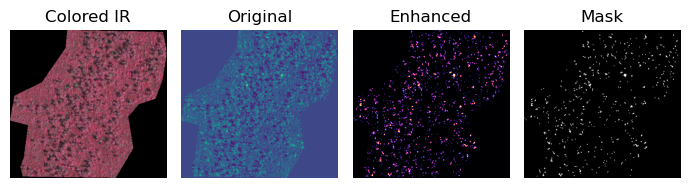


 26%|██████                 | 11/42 [00:01<00:03,  9.18it/s]

../../rawImage/raw_m_3507517_sw_18_060_20200516.tif



  0%|                                | 0/38 [00:00<?, ?it/s]

255.0


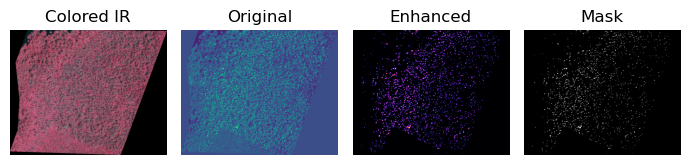


  3%|▋                       | 1/38 [00:00<00:07,  4.96it/s]

255.0


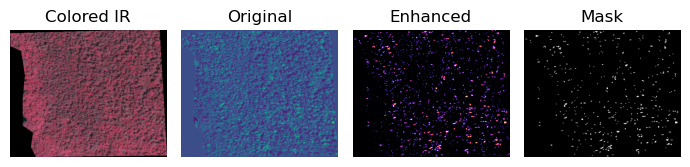


  5%|█▎                      | 2/38 [00:00<00:05,  6.59it/s]

255.0


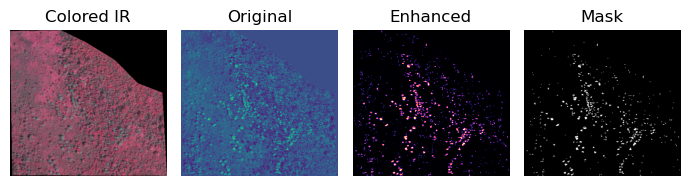


  8%|█▉                      | 3/38 [00:00<00:05,  6.91it/s]

255.0


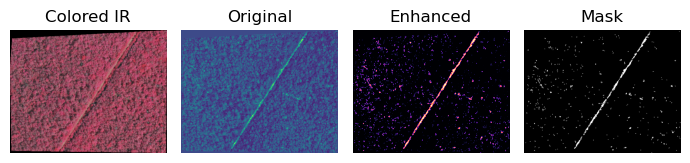


 50%|███████████▌           | 19/38 [00:00<00:00, 41.41it/s]

255.0


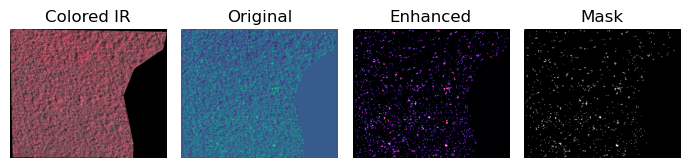


 84%|███████████████████▎   | 32/38 [00:00<00:00, 56.71it/s]

255.0


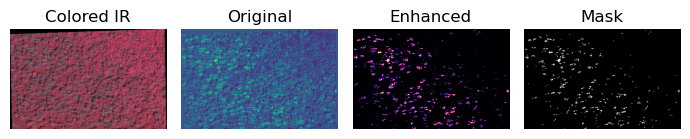

255.0


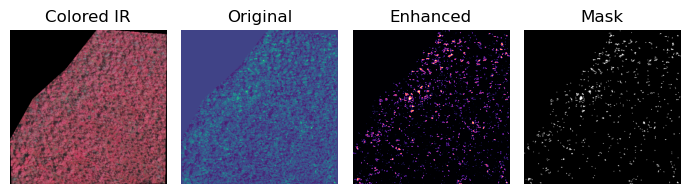


100%|███████████████████████| 38/38 [00:01<00:00, 36.45it/s]


../../rawImage/raw_m_3507510_se_18_060_20200516.tif



  0%|                                | 0/38 [00:00<?, ?it/s]

255.0


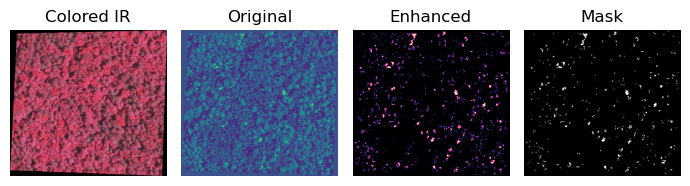


 18%|████▍                   | 7/38 [00:00<00:00, 56.47it/s]

255.0


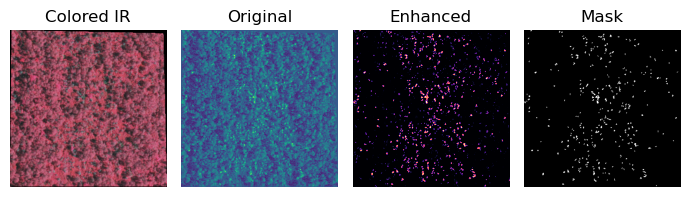


 31%|███████                | 13/42 [00:02<00:07,  3.64it/s]

../../rawImage/raw_m_3507501_sw_18_1_20100704.tif



100%|██████████████████████| 38/38 [00:00<00:00, 974.33it/s]


../../rawImage/raw_m_3507501_ne_18_060_20200516.tif



100%|██████████████████████| 38/38 [00:00<00:00, 847.83it/s]


../../rawImage/raw_m_3507616_ne_18_060_20200516.tif



 38%|████████▊              | 16/42 [00:02<00:04,  5.43it/s]

../../rawImage/raw_m_3507510_sw_18_060_20200516.tif



  0%|                                | 0/38 [00:00<?, ?it/s]

255.0


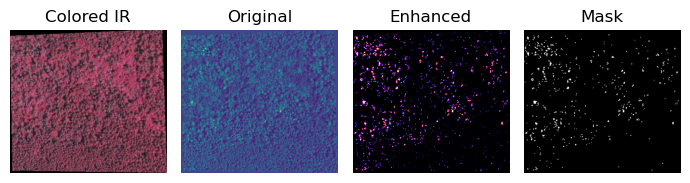


100%|██████████████████████| 38/38 [00:00<00:00, 240.73it/s]


../../rawImage/raw_m_3507501_nw_18_060_20200516.tif



 43%|█████████▊             | 18/42 [00:03<00:03,  6.19it/s]

../../rawImage/raw_m_3507525_ne_18_060_20200516.tif



100%|██████████████████████| 38/38 [00:00<00:00, 966.26it/s]


../../rawImage/raw_m_3507502_sw_18_060_20200516.tif



  0%|                                | 0/38 [00:00<?, ?it/s]

255.0


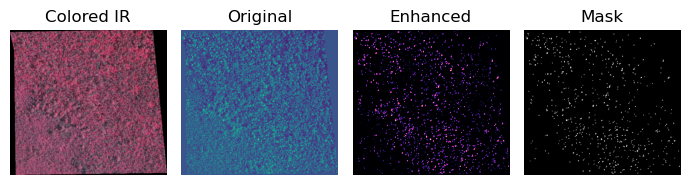


 48%|██████████▉            | 20/42 [00:03<00:03,  6.50it/s]

../../rawImage/raw_m_3507624_se_18_060_20200516.tif



100%|█████████████████████| 38/38 [00:00<00:00, 1072.56it/s]


../../rawImage/raw_m_3507519_nw_18_060_20200516.tif



  0%|                                | 0/38 [00:00<?, ?it/s]

255.0


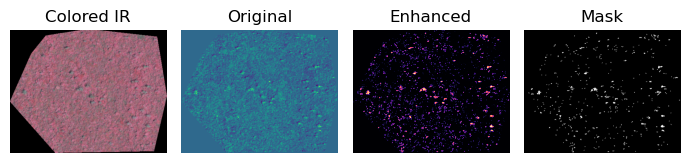


 66%|██████████████▍       | 25/38 [00:00<00:00, 172.49it/s]

255.0


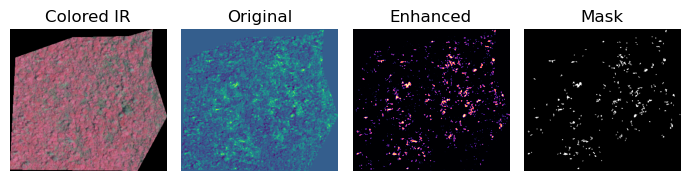

 52%|████████████           | 22/42 [00:03<00:03,  6.51it/s]

../../rawImage/raw_m_3507525_nw_18_060_20200516.tif



  0%|                                | 0/38 [00:00<?, ?it/s]

255.0


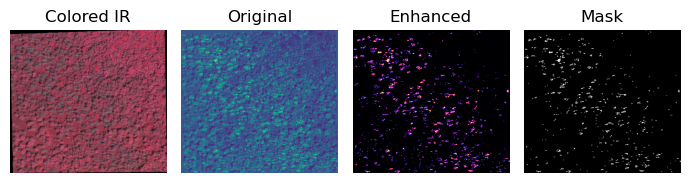


 87%|███████████████████   | 33/38 [00:00<00:00, 209.78it/s]

255.0


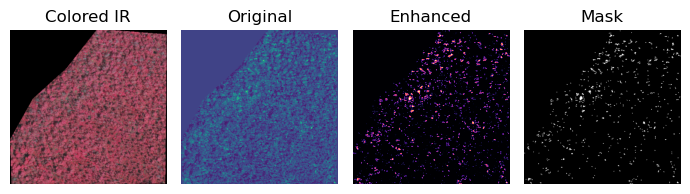

 55%|████████████▌          | 23/42 [00:03<00:03,  5.62it/s]

../../rawImage/raw_m_3507502_se_18_060_20200516.tif



100%|█████████████████████| 38/38 [00:00<00:00, 1137.72it/s]


../../rawImage/raw_m_3507526_ne_18_060_20201018.tif



100%|█████████████████████| 38/38 [00:00<00:00, 1065.21it/s]


../../rawImage/raw_m_3507510_ne_18_060_20200516.tif



  0%|                                | 0/38 [00:00<?, ?it/s]

255.0


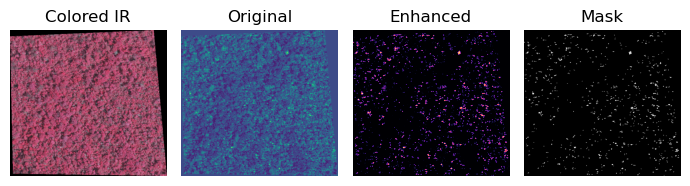


 62%|██████████████▏        | 26/42 [00:04<00:02,  7.18it/s]

../../rawImage/raw_m_3507517_nw_18_060_20200516.tif



  0%|                                | 0/38 [00:00<?, ?it/s]

255.0


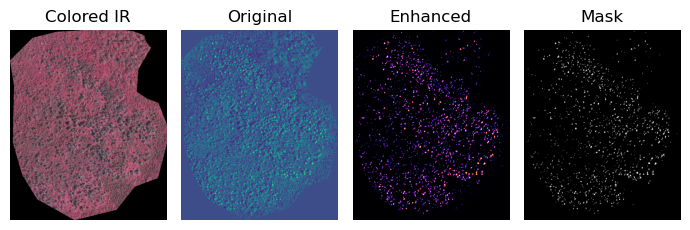


 24%|█████▋                  | 9/38 [00:00<00:00, 38.76it/s]

255.0


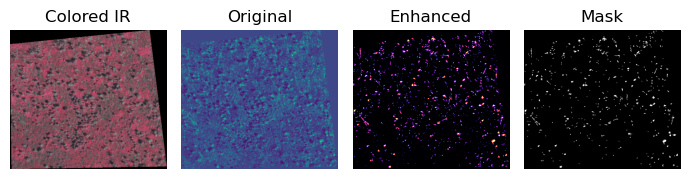


 71%|████████████████▎      | 27/38 [00:00<00:00, 66.31it/s]

255.0


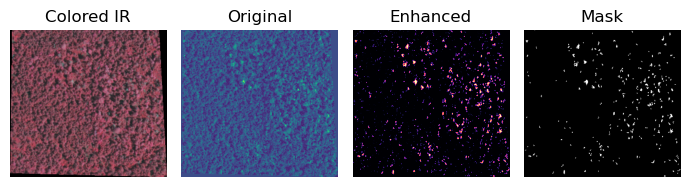


 95%|█████████████████████▊ | 36/38 [00:00<00:00, 67.79it/s]

255.0


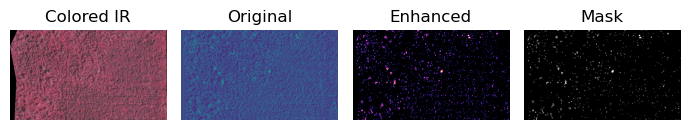

 64%|██████████████▊        | 27/42 [00:04<00:03,  4.28it/s]

../../rawImage/raw_m_3507501_se_18_060_20200516.tif



100%|█████████████████████| 38/38 [00:00<00:00, 1004.78it/s]


../../rawImage/raw_m_3507616_se_18_060_20200516.tif



100%|█████████████████████| 38/38 [00:00<00:00, 1025.75it/s]


../../rawImage/raw_m_3507526_nw_18_060_20201018.tif



 71%|████████████████▍      | 30/42 [00:05<00:01,  6.55it/s]

../../rawImage/raw_m_3507517_ne_18_060_20200516.tif



  0%|                                | 0/38 [00:00<?, ?it/s]

255.0


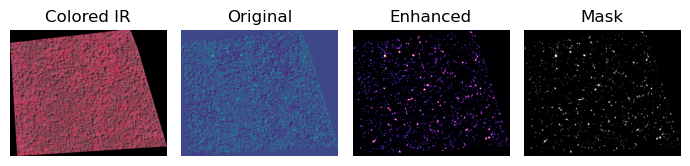


 63%|██████████████▌        | 24/38 [00:00<00:00, 96.89it/s]

255.0


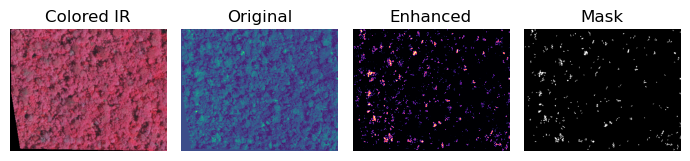


 89%|████████████████████▌  | 34/38 [00:00<00:00, 91.61it/s]

255.0


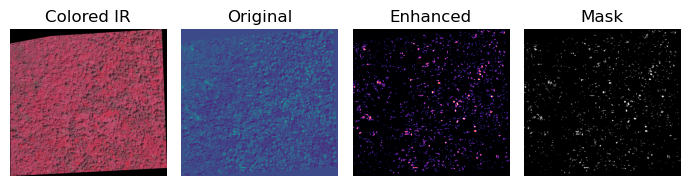

100%|███████████████████████| 38/38 [00:00<00:00, 65.51it/s]


../../rawImage/raw_m_3507510_nw_18_060_20200516.tif



  0%|                                | 0/38 [00:00<?, ?it/s]

255.0


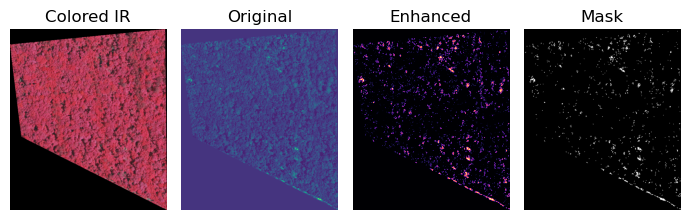


 76%|█████████████████▌     | 32/42 [00:05<00:02,  4.48it/s]

../../rawImage/raw_m_3507501_sw_18_060_20200516.tif



100%|██████████████████████| 38/38 [00:00<00:00, 974.51it/s]


../../rawImage/raw_m_3507511_nw_18_060_20200516.tif



100%|██████████████████████| 38/38 [00:00<00:00, 981.66it/s]


../../rawImage/raw_m_3507527_nw_18_060_20201018.tif



 83%|███████████████████▏   | 35/42 [00:05<00:01,  6.45it/s]

../../rawImage/raw_m_3507518_ne_18_060_20200516.tif



  0%|                                | 0/38 [00:00<?, ?it/s]

255.0


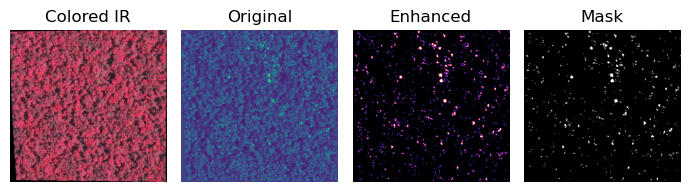


 34%|███████▊               | 13/38 [00:00<00:00, 57.13it/s]

255.0


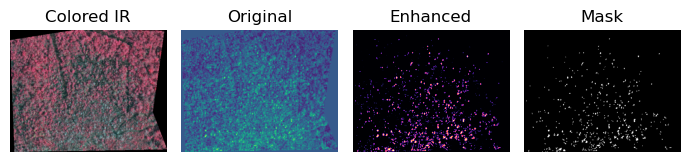


 82%|██████████████████▊    | 31/38 [00:00<00:00, 89.99it/s]

255.0


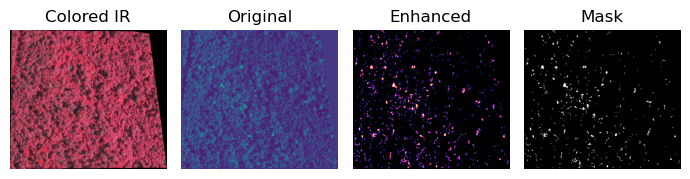

100%|███████████████████████| 38/38 [00:00<00:00, 75.08it/s]


../../rawImage/raw_m_3507509_se_18_060_20200516.tif



  0%|                                | 0/38 [00:00<?, ?it/s]

255.0


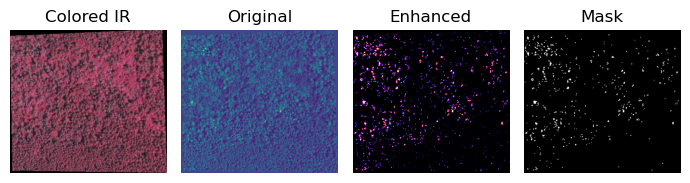


 13%|███▏                    | 5/38 [00:00<00:00, 39.68it/s]

255.0


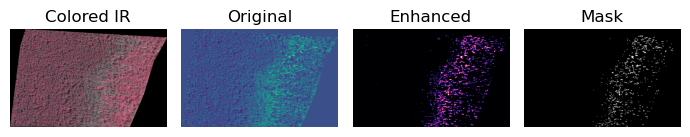


 37%|████████▍              | 14/38 [00:00<00:00, 56.25it/s]

255.0


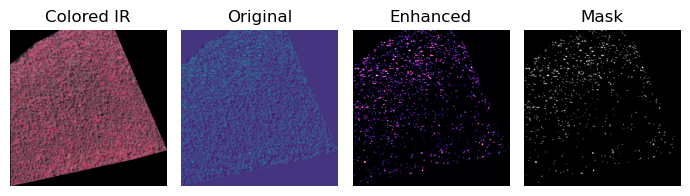

255.0


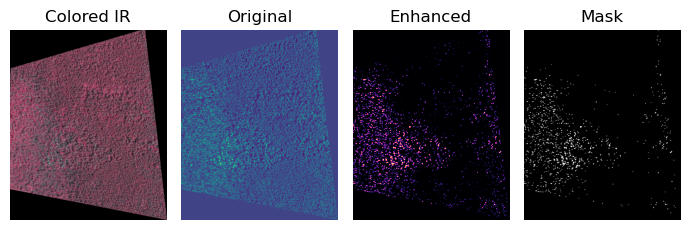


 53%|████████████           | 20/38 [00:00<00:00, 32.34it/s]

255.0


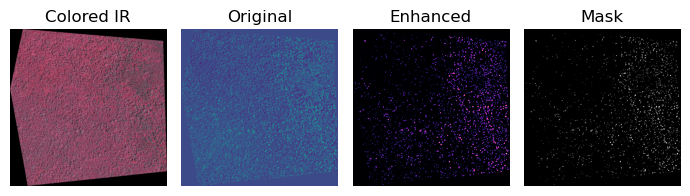


 63%|██████████████▌        | 24/38 [00:00<00:00, 22.85it/s]

255.0


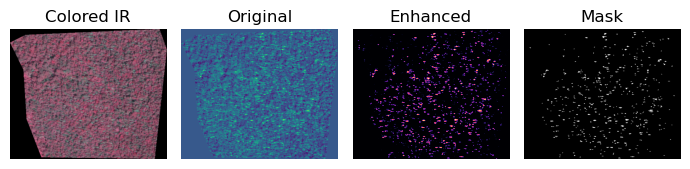


 76%|█████████████████▌     | 29/38 [00:00<00:00, 26.70it/s]

255.0


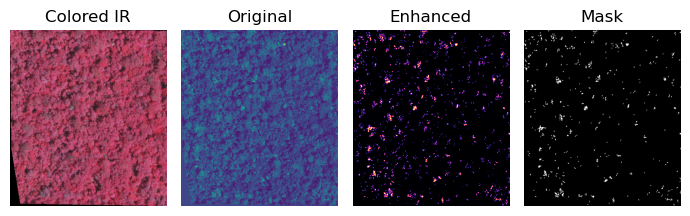


 88%|████████████████████▎  | 37/42 [00:07<00:01,  3.01it/s]

../../rawImage/raw_m_3507608_ne_18_060_20200516.tif



100%|██████████████████████| 38/38 [00:00<00:00, 988.93it/s]


../../rawImage/raw_m_3507518_nw_18_060_20200516.tif



100%|██████████████████████| 38/38 [00:00<00:00, 925.09it/s]


../../rawImage/raw_m_3507509_sw_18_060_20200516.tif



  0%|                                | 0/38 [00:00<?, ?it/s]

255.0


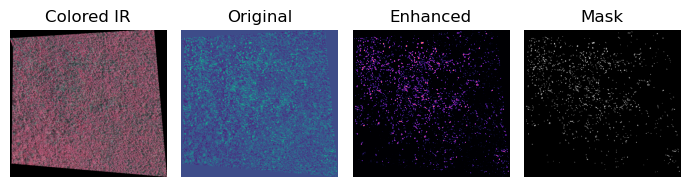


 45%|██████████▎            | 17/38 [00:00<00:00, 88.59it/s]

255.0


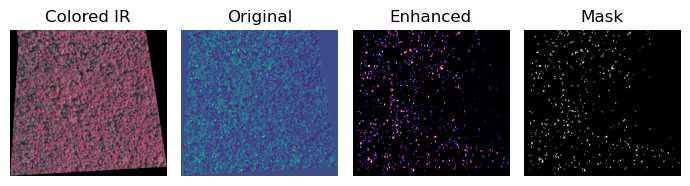


 68%|███████████████▋       | 26/38 [00:00<00:00, 80.35it/s]

255.0


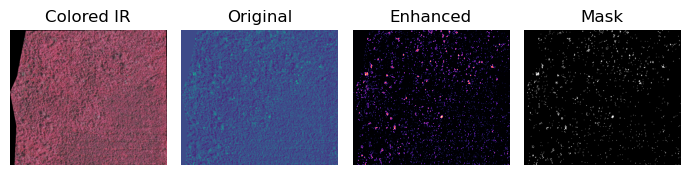


 95%|█████████████████████▉ | 40/42 [00:08<00:00,  3.53it/s]

../../rawImage/raw_m_3507503_sw_18_060_20200516.tif



100%|█████████████████████| 38/38 [00:00<00:00, 1012.25it/s]


../../rawImage/raw_m_3507501_nw_18_1_20100704.tif



100%|███████████████████████| 42/42 [00:08<00:00,  5.07it/s]


In [444]:
def batchProcess(inputImages, training_base_dir, training_area_fn, outDir, outFilenamePrefix):
    if not os.path.exists(outDir):
        os.makedirs(outDir)
    
    # Read training areas within the shapefile
    with fiona.open(os.path.join(training_base_dir, training_area_fn), "r") as shapefile:
        trainingAreas = [feature["geometry"] for feature in shapefile]
        print('Found number of training areas:', len(trainingAreas))

    for imgs in tqdm(inputImages):
        print(imgs[0])
        for i in tqdm(range(len(trainingAreas))):
            Area = [trainingAreas[i]]
            # Get bounding box of the training area
            Area_bounds = shape(Area[0]).bounds
            bboxArea = box(*Area_bounds)

            with rasterio.open(imgs[0]) as src:
                # Get bounding box of the raster image 
                bboxIm = box(*src.bounds)
                if (bboxArea.intersects(bboxIm)):
                    image, transform = rasterio.mask.mask(src, Area, all_touched=True, crop=True)
                    meta = src.meta
                    image = image.astype(float)
                    im_name = '_'+os.path.basename(src.name)
                    r, g, b, n = image[0], image[1], image[2], image[3]
                    
                    # Colored infra-red
                    cir = np.stack((n,r,g),axis=-1).astype('uint8')
                    
                    rgir = r * (r / g)
                    rgir[np.isnan(rgir)] = 0
                    im = rgir.astype('uint8')

#                     m_nr = np.absolute((n-r)/(845-635)) # slope of NIR and Red
#                     m_gb = np.absolute((g-b)/(555-465)) # slope of Green and Blue
#                     ssi = (m_nr - m_gb)/(m_nr + m_gb) * -1
# #                     im = ssi.astype('uint8')
#                     scaled_arr = (ssi * 127.5 + 127.5)
#                     im = np.round(scaled_arr).astype(np.uint8)

                    # Write path
                    file_path = os.path.join(outDir, outFilenamePrefix+str(i)+im_name)
                    processImageAndWriteMask(cir, im, meta, transform, file_path, method='percentile', gamma=3, min_size=3, contrast_stretch=True, relabel=False, write=True)

# Batch generating images
batchProcess(inputImages, training_base_dir, training_area_fn, outDir, outFilenamePrefix)

The Code Ends Here

In [286]:
im = rasterio.open(inputImages[11][0]).read().astype(float)[:,500:1500,4000:5000]

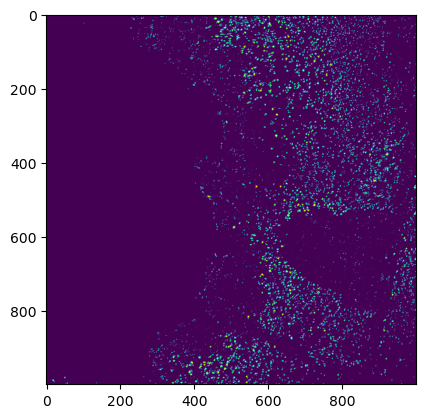

In [300]:
r,g,b,n = im[0], im[1], im[2], im[3]
rgir = r * (r/g)
v_min, v_max = np.percentile(rgir, (90, 98))
img = exposure.rescale_intensity(rgir, in_range=(v_min, v_max))
img = exposure.adjust_gamma(img, 4)
plt.imshow(img)
plt.show()

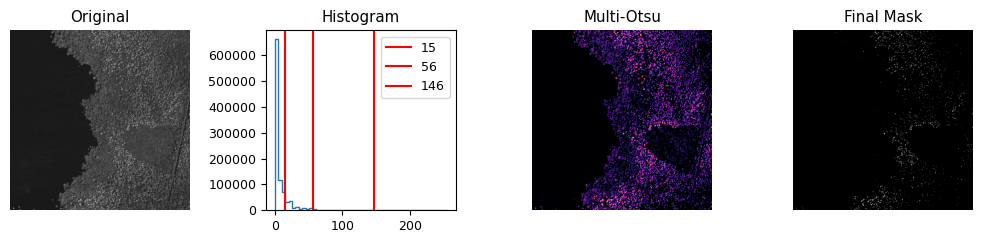

In [185]:
import matplotlib
import matplotlib.pyplot as plt
import numpy as np

from skimage import data
from skimage.filters import threshold_multiotsu, rank
from skimage.morphology import remove_small_objects
from skimage import exposure

# Setting the font size for all plots.
matplotlib.rcParams['font.size'] = 9

# The input image.
image_ori = b
v_min, v_max = np.percentile(image_ori, (0.2, 99.8))
image = exposure.rescale_intensity(image_ori, in_range=(v_min, v_max))
image = exposure.adjust_gamma(image, 3)


# Applying multi-Otsu threshold for the default value, generating
# three classes.
thresholds = threshold_multiotsu(image, classes=4)

# Using the threshold values, we generate the three regions.
regions = np.digitize(image, bins=thresholds)

# Create final mask\
mask = image >= thresholds[-1]

fig, ax = plt.subplots(nrows=1, ncols=4, figsize=(10, 2.5))

# Plotting the original image.
ax[0].imshow(image_ori, cmap='gray')
ax[0].set_title('Original')
ax[0].axis('off')

# Plotting the histogram and the two thresholds obtained from
# multi-Otsu.
ax[1].hist(image.ravel(), bins=50, histtype='step')
ax[1].set_title('Histogram')
for thresh in thresholds:
    ax[1].axvline(thresh, color='r', label=thresh)
ax[1].legend(loc='upper right')

# Plotting the Multi Otsu result.
ax[2].imshow(regions, cmap='magma')
ax[2].set_title('Multi-Otsu')
ax[2].axis('off')

# Plotting the Final Otsu result.
ax[3].imshow(mask, cmap='gray')
ax[3].set_title('Final Mask')
ax[3].axis('off')

plt.subplots_adjust()
plt.tight_layout()
plt.show()

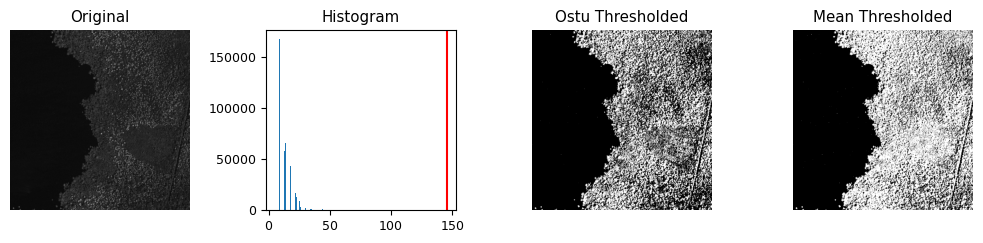

In [186]:
# Global Mean and Otsu Thresholding
# Otsu method calculates an “optimal” threshold (marked by a red line in the histogram below) 
# by maximizing the variance between two classes of pixels, which are separated by the threshold. 
# Equivalently, this threshold minimizes the intra-class variance.

from skimage.filters import threshold_otsu, threshold_mean

# The input image.
image_ori = b
v_min, v_max = np.percentile(image_ori, (0.2, 99.8))
image = exposure.rescale_intensity(image_ori, in_range=(v_min, v_max))
image = exposure.adjust_gamma(image_ori, 2)

thresh_ostu = threshold_otsu(image)
binary_ostu = image > thresh_ostu

thresh_mean = threshold_mean(image)
binary_mean = image > thresh_mean

fig, axes = plt.subplots(ncols=4, figsize=(10, 2.5))
ax = axes.ravel()
ax[0] = plt.subplot(1, 4, 1)
ax[1] = plt.subplot(1, 4, 2)
ax[2] = plt.subplot(1, 4, 3)
ax[3] = plt.subplot(1, 4, 4, sharex=ax[0], sharey=ax[0])

ax[0].imshow(image, cmap=plt.cm.gray)
ax[0].set_title('Original')
ax[0].axis('off')

ax[1].hist(image.ravel(), bins=256)
ax[1].set_title('Histogram')
ax[1].axvline(thresh, color='r')

ax[2].imshow(binary_ostu, cmap=plt.cm.gray)
ax[2].set_title('Ostu Thresholded')
ax[2].axis('off')

ax[3].imshow(binary_mean, cmap=plt.cm.gray)
ax[3].set_title('Mean Thresholded')
ax[3].axis('off')
plt.tight_layout()
plt.show()

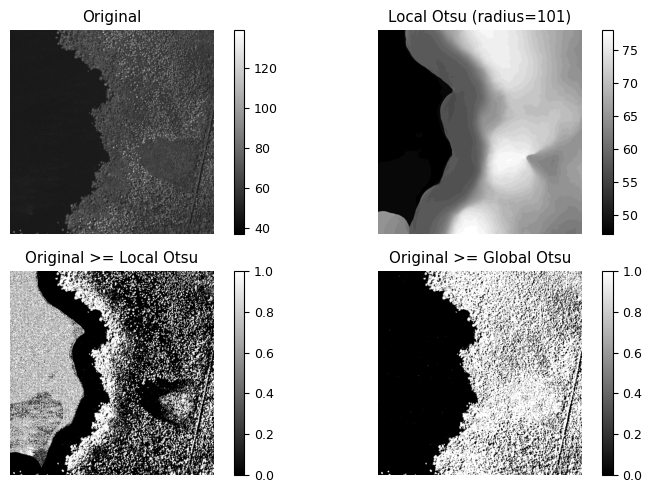

In [192]:
# Global Ostu vs Ostu Adaptive Tresholding
from skimage.morphology import disk
from skimage.filters import threshold_otsu, rank
from skimage.util import img_as_ubyte


# The input image.
img = b

radius = 101
footprint = disk(radius)

local_otsu = rank.otsu(img, footprint)
threshold_global_otsu = threshold_otsu(img)
global_otsu = img >= threshold_global_otsu

fig, axes = plt.subplots(2, 2, figsize=(8, 5), sharex=True, sharey=True)
ax = axes.ravel()

fig.colorbar(ax[0].imshow(img, cmap=plt.cm.gray), ax=ax[0])
ax[0].set_title('Original')
ax[0].axis('off')

fig.colorbar(ax[1].imshow(local_otsu, cmap=plt.cm.gray),ax=ax[1])
ax[1].set_title(f'Local Otsu (radius={radius})')
ax[1].axis('off')

fig.colorbar(ax[2].imshow(img >= local_otsu, cmap=plt.cm.gray),ax=ax[2])
ax[2].imshow(img >= local_otsu, cmap=plt.cm.gray)
ax[2].set_title('Original >= Local Otsu')
ax[2].axis('off')

fig.colorbar(ax[3].imshow(global_otsu, cmap=plt.cm.gray),ax=ax[3])
ax[3].imshow(global_otsu, cmap=plt.cm.gray)
ax[3].set_title('Original >= Global Otsu')
ax[3].axis('off')
plt.tight_layout()
plt.show()

In [ ]:
# # Adaptive Thresholding
# from skimage.filters import threshold_otsu, threshold_local, threshold_niblack, threshold_sauvola


# image = b_band

# global_thresh = threshold_otsu(image)
# binary_global = image > global_thresh

# block_size = 55
# local_thresh = threshold_local(image, block_size, method='gaussian', offset=10)
# thresh_niblack = threshold_niblack(image, window_size=block_size, k=0.8)
# thresh_sauvola = threshold_sauvola(image, window_size=block_size)

# binary_local = image < local_thresh
# binary_niblack = image < thresh_niblack
# binary_sauvola = image < thresh_sauvola

# fig, axes = plt.subplots(ncols=3, nrows=2, figsize=(13, 13))
# ax = axes.ravel()
# plt.gray()

# ax[0].imshow(image)
# ax[0].set_title('Original')

# ax[1].imshow(binary_global)
# ax[1].set_title('Global thresholding')

# ax[2].imshow(binary_local)
# ax[2].set_title('Local thresholding')

# ax[3].imshow(binary_niblack)
# ax[3].set_title('Niblack thresholding')

# ax[4].imshow(binary_sauvola)
# ax[4].set_title('Sauvola thresholding')

# for a in ax:
#     a.axis('off')

# plt.show()
